In [1]:
# !pip install torch torchvision pillow matplotlib numpy
import torch
import torchvision
from torchvision import transforms as T
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2

# The V2 weights are significantly more accurate than the original
from torchvision.models.detection import maskrcnn_resnet50_fpn_v2, MaskRCNN_ResNet50_FPN_V2_Weights

weights = MaskRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model = maskrcnn_resnet50_fpn_v2(weights=weights)
model.eval()



MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         

In [2]:
def refine_mask_with_grabcut(img_np, binary_mask):
    """Refines the rough CNN mask using image color gradients."""
    mask_gc = np.where(binary_mask, cv2.GC_PR_FGD, cv2.GC_PR_BGD).astype('uint8')
    bgdModel = np.zeros((1, 65), np.float64)
    fgdModel = np.zeros((1, 65), np.float64)
    
    # GrabCut refines the mask based on pixel color distribution
    cv2.grabCut(img_np, mask_gc, None, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_MASK)
    
    # Create final mask: pixels that are definitely or probably foreground
    final_mask = np.where((mask_gc == 2) | (mask_gc == 0), 0, 1).astype('uint8')
    return final_mask

In [5]:
def blackout_people(image_path):
    img = Image.open(image_path).convert("RGB")
    img_np = np.array(img)
    img_tensor = T.ToTensor()(img)
    
    with torch.no_grad():
        prediction = model([img_tensor])
    
    masks = prediction[0]['masks'].cpu().numpy()
    labels = prediction[0]['labels'].cpu().numpy()
    scores = prediction[0]['scores'].cpu().numpy()
    
    # Final canvas
    output_img = img_np.copy()
    
    for i in range(len(masks)):
        if labels[i] == 1 and scores[i] > 0.8: # High confidence only
            # Initial rough mask
            rough_mask = masks[i, 0] > 0.5
            
            # Refine edges using image gradients
            refined_mask = refine_mask_with_grabcut(img_np, rough_mask)
            
            # Apply blackout
            output_img[refined_mask == 1] = [0, 0, 0]
            
    return output_img

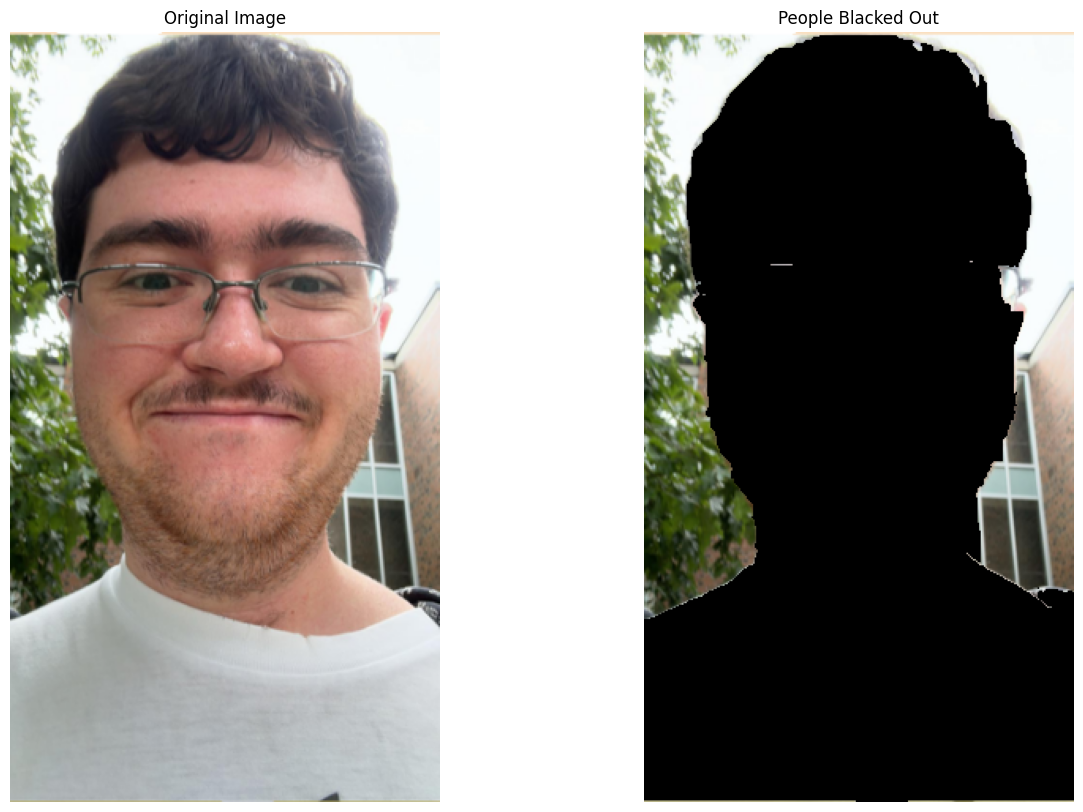

In [21]:
# Path to your image
IMAGE_PATH = "image.png" 

# Process image
result = blackout_people(IMAGE_PATH)

# Display original vs processed
original = Image.open(IMAGE_PATH)
plt.figure(figsize=(15, 10))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(original)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("People Blacked Out")
plt.imshow(result)
plt.axis('off')

plt.show()